"""
SYDE 572 Fall 2025 - Dimensionality Reduction Project
Dataset: Parkinson's Telemonitoring (UCI ML Repository)
Author: Aadithya Sairam
Date: December 2nd 2025

Project Goals:
1. Regression on original 16 voice features to predict motor_UPDRS
2. PCA dimensionality reduction with performance analysis
3. UMAP (non-linear) dimensionality reduction with performance analysis
4. Comparison of all approaches
"""

In [1]:
# ============================================================================
# SECTION 1: IMPORT LIBRARIES AND LOAD DATA
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from umap import UMAP
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("SYDE 572 - Dimensionality Reduction Project")
print("Parkinson's Telemonitoring Dataset")
print("=" * 80)


SYDE 572 - Dimensionality Reduction Project
Parkinson's Telemonitoring Dataset


In [2]:
# ============================================================================
# SECTION 2: LOAD AND EXPLORE DATASET
# ============================================================================

# Load the dataset using ucimlrepo
import pandas as pd

# Load from local file
data = pd.read_csv('parkinsons_updrs.data')

# Split into features and targets
y = data[['motor_UPDRS', 'total_UPDRS']]
feature_cols = [col for col in data.columns 
               if col not in ['motor_UPDRS', 'total_UPDRS']]
X = data[feature_cols]

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")


# Display basic information
print("\n" + "=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nNumber of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names:")
print(X.columns.tolist())
print(f"\nTarget variables: {y.columns.tolist()}")

# Focus on predicting motor_UPDRS (can also do total_UPDRS)
target_name = 'motor_UPDRS'
y_motor = y[target_name]

print(f"\nTarget variable selected: {target_name}")
print(f"Target statistics:")
print(y_motor.describe())

# Check for missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y_motor.isnull().sum()}")

Features shape: (5875, 20)
Targets shape: (5875, 2)

DATASET OVERVIEW

Number of samples: 5875
Number of features: 20

Feature names:
['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Target variables: ['motor_UPDRS', 'total_UPDRS']

Target variable selected: motor_UPDRS
Target statistics:
count    5875.000000
mean       21.296229
std         8.129282
min         5.037700
25%        15.000000
50%        20.871000
75%        27.596500
max        39.511000
Name: motor_UPDRS, dtype: float64

Missing values in features: 0
Missing values in target: 0


In [3]:
# ============================================================================
# SECTION 3: DATA PREPROCESSING AND TRAIN/TEST SPLIT
# ============================================================================

print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Remove non-voice features (subject#, age, sex, test_time) to focus on voice measures
# The 16 voice features are the actual predictors we want to analyze
voice_features = [col for col in X.columns if col not in ['subject#', 'age', 'sex', 'test_time']]
X_voice = X[voice_features].copy()

print(f"\nUsing {len(voice_features)} voice features:")
print(voice_features)

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_voice, y_motor, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Standardize the features (important for PCA and UMAP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized (zero mean, unit variance)")

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=voice_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=voice_features, index=X_test.index)



DATA PREPROCESSING

Using 16 voice features:
['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Train set size: 4700 samples
Test set size: 1175 samples

Features standardized (zero mean, unit variance)


In [4]:
# ============================================================================
# SECTION 4: BASELINE REGRESSION ON ORIGINAL FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("BASELINE REGRESSION - ALL ORIGINAL FEATURES")
print("=" * 80)

# We'll use Ridge Regression as the baseline model
baseline_model = Ridge(alpha=1.0, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_baseline = baseline_model.predict(X_train_scaled)
y_test_pred_baseline = baseline_model.predict(X_test_scaled)

# Performance metrics
train_rmse_baseline = np.sqrt(mean_squared_error(y_train, y_train_pred_baseline))
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_test_pred_baseline))
train_mae_baseline = mean_absolute_error(y_train, y_train_pred_baseline)
test_mae_baseline = mean_absolute_error(y_test, y_test_pred_baseline)
train_r2_baseline = r2_score(y_train, y_train_pred_baseline)
test_r2_baseline = r2_score(y_test, y_test_pred_baseline)

print(f"\nBaseline Model Performance (Ridge Regression):")
print(f"  Training Set:")
print(f"    - RMSE: {train_rmse_baseline:.4f}")
print(f"    - MAE:  {train_mae_baseline:.4f}")
print(f"    - R²:   {train_r2_baseline:.4f}")
print(f"\n  Test Set:")
print(f"    - RMSE: {test_rmse_baseline:.4f}")
print(f"    - MAE:  {test_mae_baseline:.4f}")
print(f"    - R²:   {test_r2_baseline:.4f}")

# Store baseline results
baseline_results = {
    'n_features': len(voice_features),
    'train_rmse': train_rmse_baseline,
    'test_rmse': test_rmse_baseline,
    'train_r2': train_r2_baseline,
    'test_r2': test_r2_baseline
}




BASELINE REGRESSION - ALL ORIGINAL FEATURES

Baseline Model Performance (Ridge Regression):
  Training Set:
    - RMSE: 7.6851
    - MAE:  6.5017
    - R²:   0.1136

  Test Set:
    - RMSE: 7.6812
    - MAE:  6.5561
    - R²:   0.0757



PCA - LINEAR DIMENSIONALITY REDUCTION

PCA Results:
  Number of components: 16

  Explained variance by component:
    PC1: 0.7055 (cumulative: 0.7055)
    PC2: 0.1048 (cumulative: 0.8102)
    PC3: 0.0763 (cumulative: 0.8865)
    PC4: 0.0481 (cumulative: 0.9346)
    PC5: 0.0187 (cumulative: 0.9534)
    PC6: 0.0140 (cumulative: 0.9674)
    PC7: 0.0109 (cumulative: 0.9782)
    PC8: 0.0096 (cumulative: 0.9878)
    PC9: 0.0063 (cumulative: 0.9941)
    PC10: 0.0029 (cumulative: 0.9971)
    PC11: 0.0013 (cumulative: 0.9984)
    PC12: 0.0008 (cumulative: 0.9992)
    PC13: 0.0005 (cumulative: 0.9997)
    PC14: 0.0003 (cumulative: 1.0000)
    PC15: 0.0000 (cumulative: 1.0000)
    PC16: 0.0000 (cumulative: 1.0000)


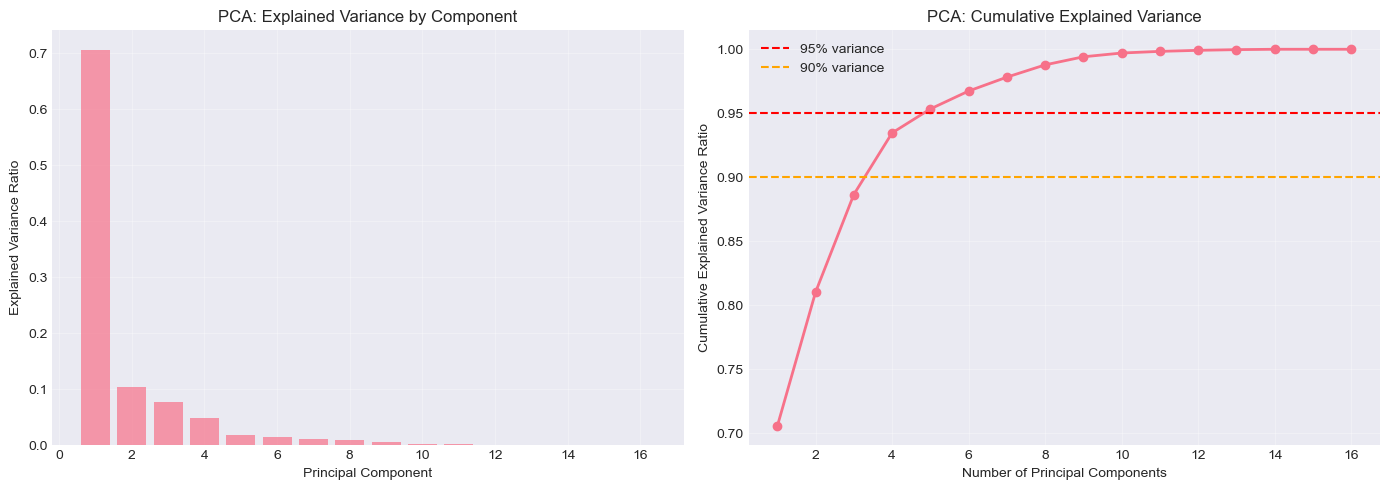


  Components needed for 90% variance: 4
  Components needed for 95% variance: 5


In [5]:
# ============================================================================
# SECTION 5: PCA DIMENSIONALITY REDUCTION (LINEAR)
# ============================================================================

print("\n" + "=" * 80)
print("PCA - LINEAR DIMENSIONALITY REDUCTION")
print("=" * 80)

# Fit PCA on training data
pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"\nPCA Results:")
print(f"  Number of components: {len(explained_variance_ratio)}")
print(f"\n  Explained variance by component:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance_ratio)):
    print(f"    PC{i+1}: {var:.4f} (cumulative: {cum_var:.4f})")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Explained Variance by Component')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 
             marker='o', linestyle='-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance Ratio')
axes[1].set_title('PCA: Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  Components needed for 90% variance: {np.argmax(cumulative_variance_ratio >= 0.90) + 1}")
print(f"  Components needed for 95% variance: {np.argmax(cumulative_variance_ratio >= 0.95) + 1}")




VISUALIZING DATA IN PCA SPACE


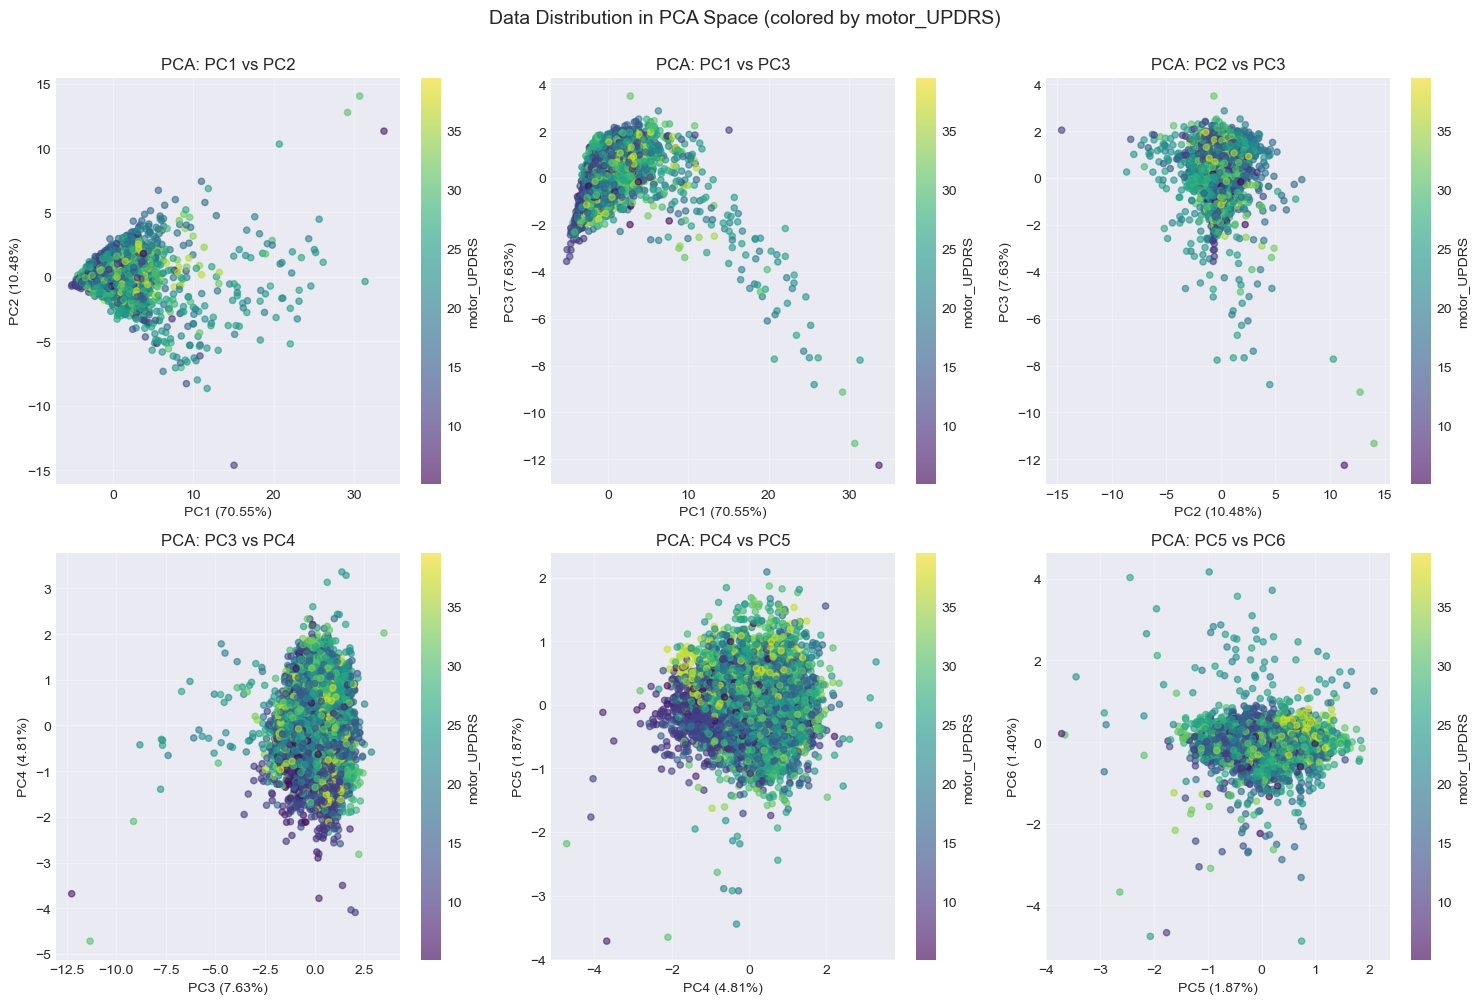


PCA visualization plots saved.


In [6]:
# ============================================================================
# SECTION 6: VISUALIZE DATA IN PCA SPACE
# ============================================================================

print("\n" + "=" * 80)
print("VISUALIZING DATA IN PCA SPACE")
print("=" * 80)

# Create 2D scatter plots of first few principal components
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Define pairs of PCs to plot
pc_pairs = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (4, 5)]

for idx, (pc1, pc2) in enumerate(pc_pairs):
    if pc1 < X_train_pca.shape[1] and pc2 < X_train_pca.shape[1]:
        scatter = axes[idx].scatter(X_train_pca[:, pc1], X_train_pca[:, pc2], 
                                   c=y_train, cmap='viridis', alpha=0.6, s=20)
        axes[idx].set_xlabel(f'PC{pc1+1} ({explained_variance_ratio[pc1]:.2%})')
        axes[idx].set_ylabel(f'PC{pc2+1} ({explained_variance_ratio[pc2]:.2%})')
        axes[idx].set_title(f'PCA: PC{pc1+1} vs PC{pc2+1}')
        axes[idx].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[idx], label='motor_UPDRS')

plt.suptitle('Data Distribution in PCA Space (colored by motor_UPDRS)', y=1.00, fontsize=14)
plt.tight_layout()
plt.savefig('pca_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPCA visualization plots saved.")


REGRESSION PERFORMANCE VS NUMBER OF PCA COMPONENTS

--------------------------------------------------------------------------------
 N Comp |  Train RMSE |   Test RMSE |  Train R² |   Test R²
--------------------------------------------------------------------------------
      1 |      8.1163 |      7.9320 |    0.0113 |    0.0143
      2 |      8.1096 |      7.9122 |    0.0129 |    0.0192
      3 |      8.1096 |      7.9119 |    0.0129 |    0.0193
      4 |      7.9659 |      7.8749 |    0.0476 |    0.0284
      5 |      7.8266 |      7.8027 |    0.0806 |    0.0462
      6 |      7.8239 |      7.8083 |    0.0813 |    0.0448
      7 |      7.8084 |      7.8131 |    0.0849 |    0.0436
      8 |      7.7218 |      7.6999 |    0.1051 |    0.0711
      9 |      7.6969 |      7.7106 |    0.1109 |    0.0686
     10 |      7.6910 |      7.7051 |    0.1122 |    0.0699
     11 |      7.6909 |      7.7029 |    0.1122 |    0.0704
     12 |      7.6874 |      7.6927 |    0.1131 |    0.0729
     

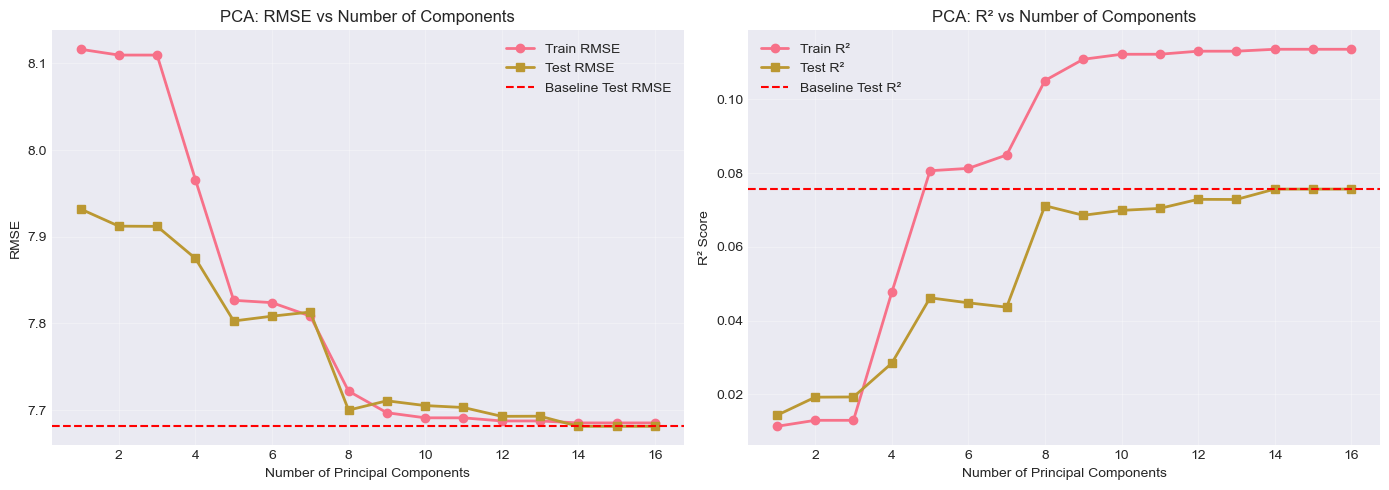


Best PCA performance:
  Number of components: 15
  Test RMSE: 7.6812
  Test R²: 0.0757


In [7]:
# ============================================================================
# SECTION 7: REGRESSION PERFORMANCE VS NUMBER OF PCA COMPONENTS
# ============================================================================


print("\n" + "=" * 80)
print("REGRESSION PERFORMANCE VS NUMBER OF PCA COMPONENTS")
print("=" * 80)


# Test performance with different numbers of PCA components
n_components_range = range(1, len(voice_features) + 1)
pca_train_rmse = []
pca_test_rmse = []
pca_train_r2 = []
pca_test_r2 = []


print("\n" + "-" * 80)
print(f"{'N Comp':>7} | {'Train RMSE':>11} | {'Test RMSE':>11} | {'Train R²':>9} | {'Test R²':>9}")
print("-" * 80)


for n_comp in n_components_range:
    # Use first n_comp principal components
    X_train_pca_n = X_train_pca[:, :n_comp]
    X_test_pca_n = X_test_pca[:, :n_comp]


    # Train model
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train_pca_n, y_train)


    # Predictions
    y_train_pred = model.predict(X_train_pca_n)
    y_test_pred = model.predict(X_test_pca_n)


    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    pca_train_rmse.append(train_rmse)
    pca_test_rmse.append(test_rmse)
    pca_train_r2.append(train_r2)
    pca_test_r2.append(test_r2)
    
    # Print performance for this number of components
    print(f"{n_comp:>7} | {train_rmse:>11.4f} | {test_rmse:>11.4f} | {train_r2:>9.4f} | {test_r2:>9.4f}")


print("-" * 80)
print(f"\nCompleted PCA regression analysis for {len(n_components_range)} different component counts")


# Plot performance vs number of components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# RMSE plot
axes[0].plot(n_components_range, pca_train_rmse, marker='o', label='Train RMSE', linewidth=2)
axes[0].plot(n_components_range, pca_test_rmse, marker='s', label='Test RMSE', linewidth=2)
axes[0].axhline(y=test_rmse_baseline, color='r', linestyle='--', label='Baseline Test RMSE')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('RMSE')
axes[0].set_title('PCA: RMSE vs Number of Components')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# R² plot
axes[1].plot(n_components_range, pca_train_r2, marker='o', label='Train R²', linewidth=2)
axes[1].plot(n_components_range, pca_test_r2, marker='s', label='Test R²', linewidth=2)
axes[1].axhline(y=test_r2_baseline, color='r', linestyle='--', label='Baseline Test R²')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('R² Score')
axes[1].set_title('PCA: R² vs Number of Components')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('pca_performance_vs_components.png', dpi=300, bbox_inches='tight')
plt.show()


# Find best number of components
best_pca_idx = np.argmin(pca_test_rmse)
best_pca_n_comp = best_pca_idx + 1
print(f"\nBest PCA performance:")
print(f"  Number of components: {best_pca_n_comp}")
print(f"  Test RMSE: {pca_test_rmse[best_pca_idx]:.4f}")
print(f"  Test R²: {pca_test_r2[best_pca_idx]:.4f}")

In [8]:
# ============================================================================
# SECTION 8: UMAP DIMENSIONALITY REDUCTION (NON-LINEAR)
# ============================================================================

print("\n" + "=" * 80)
print("UMAP - NON-LINEAR DIMENSIONALITY REDUCTION")
print("=" * 80)

# Apply UMAP with different n_components and evaluate
max_umap_components = min(10, len(voice_features))  # UMAP typically uses fewer components
umap_dimensions_range = range(2, max_umap_components + 1)

umap_train_rmse = []
umap_test_rmse = []
umap_train_r2 = []
umap_test_r2 = []

print(f"\nTesting UMAP with {len(list(umap_dimensions_range))} different component counts...")
print("This may take a few minutes...")

for n_comp in umap_dimensions_range:
    print(f"  Processing UMAP with {n_comp} components...", end=' ')

    # Fit UMAP
    umap_reducer = UMAP(n_components=n_comp, random_state=42, n_neighbors=15, min_dist=0.1)
    X_train_umap = umap_reducer.fit_transform(X_train_scaled)
    X_test_umap = umap_reducer.transform(X_test_scaled)

    # Train model
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train_umap, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_umap)
    y_test_pred = model.predict(X_test_umap)

    # Metrics
    umap_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    umap_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    umap_train_r2.append(r2_score(y_train, y_train_pred))
    umap_test_r2.append(r2_score(y_test, y_test_pred))

    print("Done")

# Fit UMAP with 2 components for visualization
print("\nFitting UMAP with 2 components for visualization...")
umap_2d = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_train_umap_2d = umap_2d.fit_transform(X_train_scaled)
X_test_umap_2d = umap_2d.transform(X_test_scaled)

# Fit UMAP with 3 components for 3D visualization
print("Fitting UMAP with 3 components for visualization...")
umap_3d = UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
X_train_umap_3d = umap_3d.fit_transform(X_train_scaled)

print("\nUMAP transformations complete!")


UMAP - NON-LINEAR DIMENSIONALITY REDUCTION

Testing UMAP with 9 different component counts...
This may take a few minutes...
  Processing UMAP with 2 components... Done
  Processing UMAP with 3 components... Done
  Processing UMAP with 4 components... Done
  Processing UMAP with 5 components... Done
  Processing UMAP with 6 components... Done
  Processing UMAP with 7 components... Done
  Processing UMAP with 8 components... Done
  Processing UMAP with 9 components... Done
  Processing UMAP with 10 components... Done

Fitting UMAP with 2 components for visualization...
Fitting UMAP with 3 components for visualization...

UMAP transformations complete!



VISUALIZING DATA IN UMAP SPACE


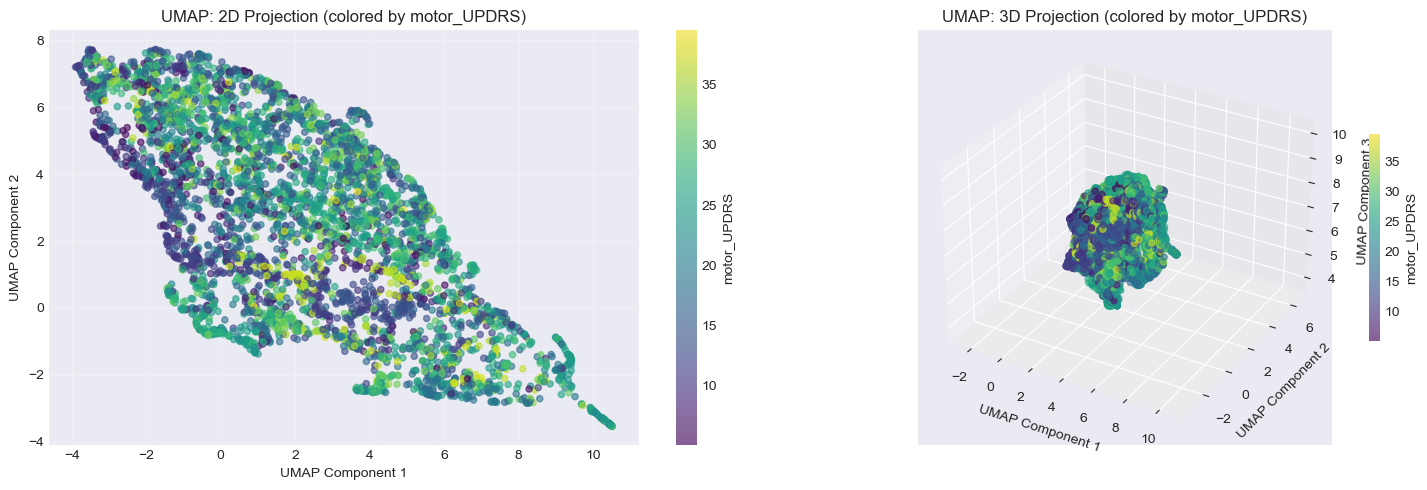


UMAP visualization plots saved.


In [9]:
# ============================================================================
# SECTION 9: VISUALIZE DATA IN UMAP SPACE
# ============================================================================

print("\n" + "=" * 80)
print("VISUALIZING DATA IN UMAP SPACE")
print("=" * 80)

fig = plt.figure(figsize=(15, 5))

# 2D UMAP visualization
ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(X_train_umap_2d[:, 0], X_train_umap_2d[:, 1], 
                       c=y_train, cmap='viridis', alpha=0.6, s=20)
ax1.set_xlabel('UMAP Component 1')
ax1.set_ylabel('UMAP Component 2')
ax1.set_title('UMAP: 2D Projection (colored by motor_UPDRS)')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='motor_UPDRS')

# 3D UMAP visualization
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_train_umap_3d[:, 0], X_train_umap_3d[:, 1], X_train_umap_3d[:, 2],
                       c=y_train, cmap='viridis', alpha=0.6, s=20)
ax2.set_xlabel('UMAP Component 1')
ax2.set_ylabel('UMAP Component 2')
ax2.set_zlabel('UMAP Component 3')
ax2.set_title('UMAP: 3D Projection (colored by motor_UPDRS)')
plt.colorbar(scatter2, ax=ax2, label='motor_UPDRS', shrink=0.5)

plt.tight_layout()
plt.savefig('umap_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nUMAP visualization plots saved.")



REGRESSION PERFORMANCE VS NUMBER OF UMAP COMPONENTS

--------------------------------------------------------------------------------
 N Comp |  Train RMSE |   Test RMSE |  Train R² |   Test R²
--------------------------------------------------------------------------------
      2 |      8.0546 |      7.8537 |    0.0263 |    0.0337
      3 |      7.9780 |      7.7921 |    0.0447 |    0.0488
      4 |      7.9662 |      7.7855 |    0.0475 |    0.0504
      5 |      7.9545 |      7.7703 |    0.0504 |    0.0541
      6 |      7.9262 |      7.7429 |    0.0571 |    0.0607
      7 |      7.8959 |      7.7061 |    0.0643 |    0.0696
      8 |      7.8766 |      7.7298 |    0.0688 |    0.0639
      9 |      7.9014 |      7.7142 |    0.0630 |    0.0677
     10 |      7.8947 |      7.7073 |    0.0646 |    0.0693
--------------------------------------------------------------------------------


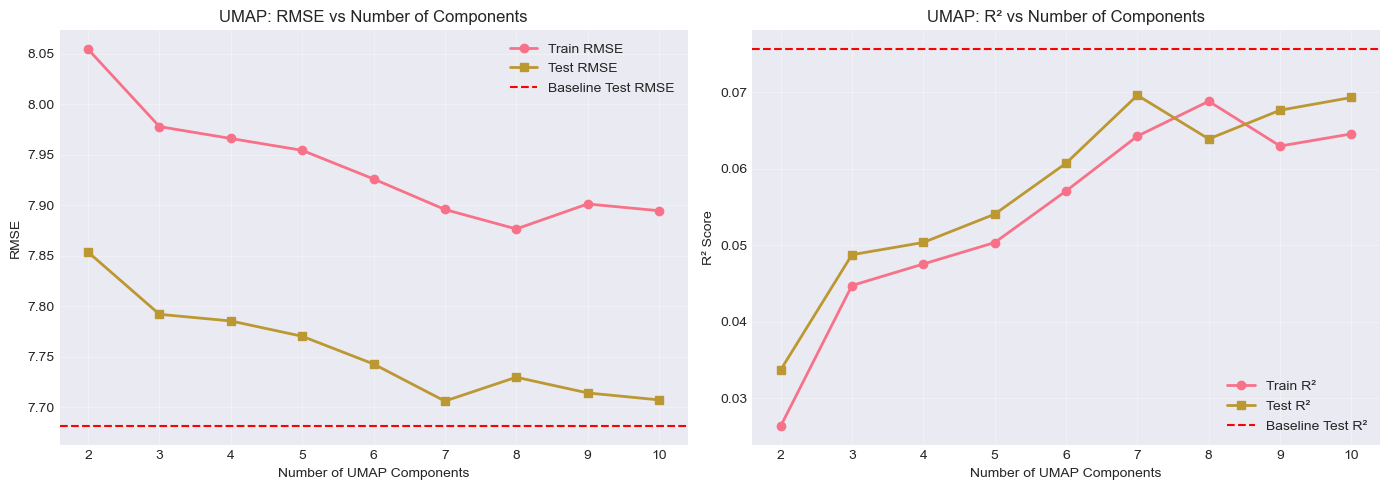


Best UMAP performance:
  Number of components: 7
  Test RMSE: 7.7061
  Test R²: 0.0696


In [10]:
# ============================================================================
# SECTION 10: REGRESSION PERFORMANCE VS NUMBER OF UMAP COMPONENTS
# ============================================================================


print("\n" + "=" * 80)
print("REGRESSION PERFORMANCE VS NUMBER OF UMAP COMPONENTS")
print("=" * 80)


# Add table header for performance tracking
print("\n" + "-" * 80)
print(f"{'N Comp':>7} | {'Train RMSE':>11} | {'Test RMSE':>11} | {'Train R²':>9} | {'Test R²':>9}")
print("-" * 80)


# Print performance for each UMAP dimension
for i, n_comp in enumerate(umap_dimensions_range):
    print(f"{n_comp:>7} | {umap_train_rmse[i]:>11.4f} | {umap_test_rmse[i]:>11.4f} | {umap_train_r2[i]:>9.4f} | {umap_test_r2[i]:>9.4f}")


print("-" * 80)


# Plot performance vs number of UMAP components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# RMSE plot
axes[0].plot(list(umap_dimensions_range), umap_train_rmse, marker='o', label='Train RMSE', linewidth=2)
axes[0].plot(list(umap_dimensions_range), umap_test_rmse, marker='s', label='Test RMSE', linewidth=2)
axes[0].axhline(y=test_rmse_baseline, color='r', linestyle='--', label='Baseline Test RMSE')
axes[0].set_xlabel('Number of UMAP Components')
axes[0].set_ylabel('RMSE')
axes[0].set_title('UMAP: RMSE vs Number of Components')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# R² plot
axes[1].plot(list(umap_dimensions_range), umap_train_r2, marker='o', label='Train R²', linewidth=2)
axes[1].plot(list(umap_dimensions_range), umap_test_r2, marker='s', label='Test R²', linewidth=2)
axes[1].axhline(y=test_r2_baseline, color='r', linestyle='--', label='Baseline Test R²')
axes[1].set_xlabel('Number of UMAP Components')
axes[1].set_ylabel('R² Score')
axes[1].set_title('UMAP: R² vs Number of Components')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('umap_performance_vs_components.png', dpi=300, bbox_inches='tight')
plt.show()


# Find best number of UMAP components
best_umap_idx = np.argmin(umap_test_rmse)
best_umap_n_comp = list(umap_dimensions_range)[best_umap_idx]
print(f"\nBest UMAP performance:")
print(f"  Number of components: {best_umap_n_comp}")
print(f"  Test RMSE: {umap_test_rmse[best_umap_idx]:.4f}")
print(f"  Test R²: {umap_test_r2[best_umap_idx]:.4f}")


COMPREHENSIVE COMPARISON OF ALL METHODS


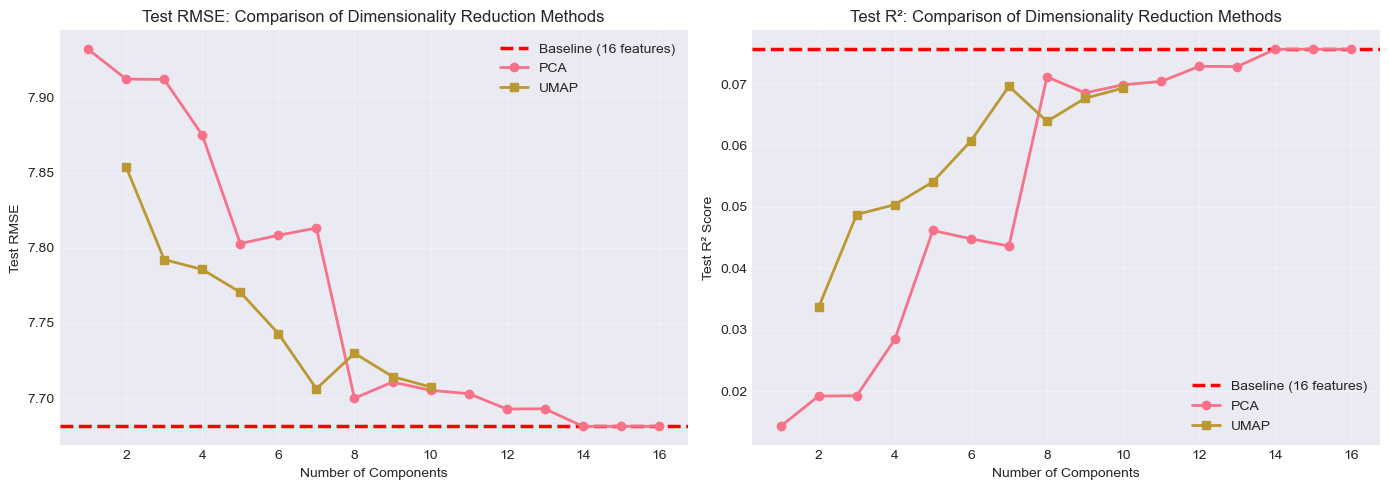


PERFORMANCE SUMMARY TABLE

                     Method Train RMSE Test RMSE Train R² Test R²
Baseline (All 16 features)     7.6851    7.6812   0.1136  0.0757
       PCA (15 components)     7.6851    7.6812   0.1136  0.0757
       UMAP (7 components)     7.8959    7.7061   0.0643  0.0696

Performance summary saved to 'performance_summary.csv'


In [11]:
# ============================================================================
# SECTION 11: COMPREHENSIVE COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("COMPREHENSIVE COMPARISON OF ALL METHODS")
print("=" * 80)

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].axhline(y=test_rmse_baseline, color='red', linestyle='--', 
               label=f'Baseline ({len(voice_features)} features)', linewidth=2.5)
axes[0].plot(n_components_range, pca_test_rmse, marker='o', label='PCA', linewidth=2, markersize=6)
axes[0].plot(list(umap_dimensions_range), umap_test_rmse, marker='s', label='UMAP', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Test RMSE')
axes[0].set_title('Test RMSE: Comparison of Dimensionality Reduction Methods')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R² comparison
axes[1].axhline(y=test_r2_baseline, color='red', linestyle='--', 
               label=f'Baseline ({len(voice_features)} features)', linewidth=2.5)
axes[1].plot(n_components_range, pca_test_r2, marker='o', label='PCA', linewidth=2, markersize=6)
axes[1].plot(list(umap_dimensions_range), umap_test_r2, marker='s', label='UMAP', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Test R² Score')
axes[1].set_title('Test R²: Comparison of Dimensionality Reduction Methods')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY TABLE")
print("=" * 80)

summary_data = {
    'Method': [
        f'Baseline (All {len(voice_features)} features)',
        f'PCA ({best_pca_n_comp} components)',
        f'UMAP ({best_umap_n_comp} components)'
    ],
    'Train RMSE': [
        f'{train_rmse_baseline:.4f}',
        f'{pca_train_rmse[best_pca_idx]:.4f}',
        f'{umap_train_rmse[best_umap_idx]:.4f}'
    ],
    'Test RMSE': [
        f'{test_rmse_baseline:.4f}',
        f'{pca_test_rmse[best_pca_idx]:.4f}',
        f'{umap_test_rmse[best_umap_idx]:.4f}'
    ],
    'Train R²': [
        f'{train_r2_baseline:.4f}',
        f'{pca_train_r2[best_pca_idx]:.4f}',
        f'{umap_train_r2[best_umap_idx]:.4f}'
    ],
    'Test R²': [
        f'{test_r2_baseline:.4f}',
        f'{pca_test_r2[best_pca_idx]:.4f}',
        f'{umap_test_r2[best_umap_idx]:.4f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# Save summary to CSV
summary_df.to_csv('performance_summary.csv', index=False)
print("\nPerformance summary saved to 'performance_summary.csv'")



FEATURE IMPORTANCE ANALYSIS (BASELINE MODEL)

Top features (by absolute coefficient magnitude):
      Feature  Coefficient  Abs_Coefficient
Shimmer:APQ11     2.499541         2.499541
 Shimmer:APQ5    -2.481279         2.481279
          DFA    -2.161428         2.161428
      Shimmer     2.069769         2.069769
          PPE     1.979224         1.979224
          HNR    -1.911534         1.911534
  Jitter(Abs)    -1.843305         1.843305
          NHR    -1.322977         1.322977
  Shimmer(dB)    -0.988371         0.988371
    Jitter(%)     0.985892         0.985892
 Shimmer:APQ3    -0.773500         0.773500
  Shimmer:DDA    -0.720157         0.720157
   Jitter:DDP     0.521701         0.521701
  Jitter:PPQ5    -0.278986         0.278986
   Jitter:RAP     0.190819         0.190819
         RPDE     0.135928         0.135928


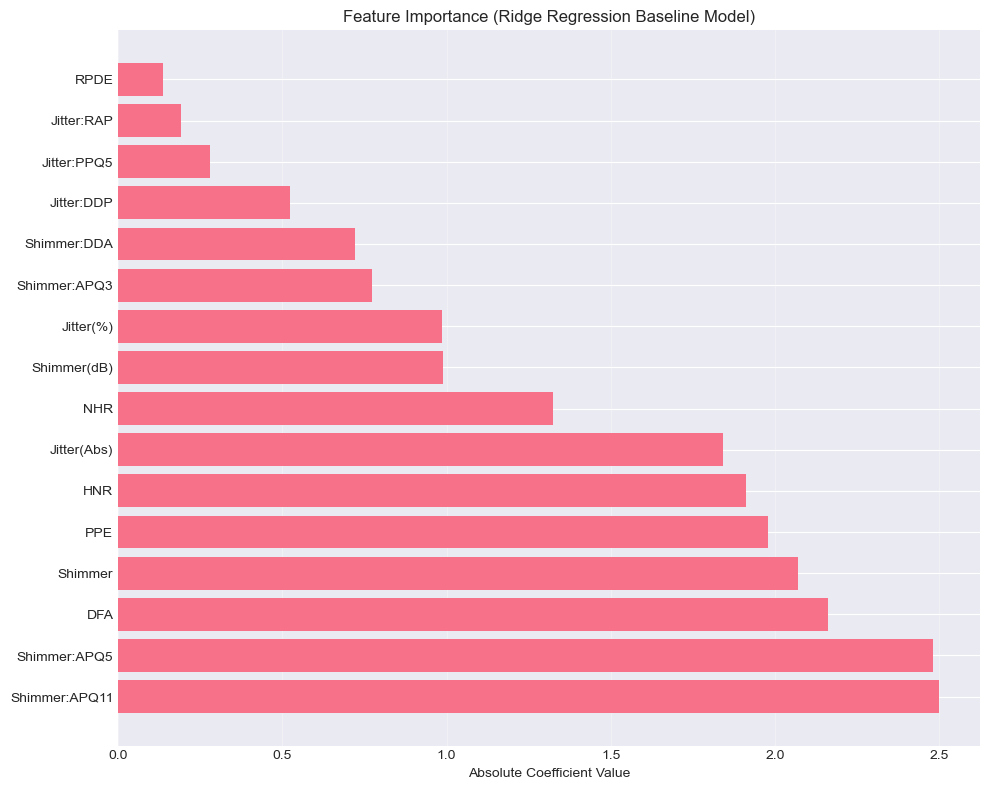

In [12]:
# ============================================================================
# SECTION 12: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS (BASELINE MODEL)")
print("=" * 80)

# Get feature importance from baseline Ridge model
feature_importance = pd.DataFrame({
    'Feature': voice_features,
    'Coefficient': baseline_model.coef_
})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\nTop features (by absolute coefficient magnitude):")
print(feature_importance.to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(feature_importance)), feature_importance['Abs_Coefficient'])
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['Feature'])
ax.set_xlabel('Absolute Coefficient Value')
ax.set_title('Feature Importance (Ridge Regression Baseline Model)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================================
# SECTION 13: FINAL OBSERVATIONS AND CONCLUSIONS
# ============================================================================

print("\n" + "=" * 80)
print("FINAL OBSERVATIONS")
print("=" * 80)

print(f"""
1. BASELINE PERFORMANCE:
   - Using all {len(voice_features)} voice features achieved Test RMSE of {test_rmse_baseline:.4f}
   - Test R² of {test_r2_baseline:.4f} indicates {test_r2_baseline*100:.1f}% of variance explained

2. PCA (LINEAR REDUCTION):
   - Best performance with {best_pca_n_comp} components (Test RMSE: {pca_test_rmse[best_pca_idx]:.4f})
   - {best_pca_n_comp} components capture {cumulative_variance_ratio[best_pca_idx-1]*100:.1f}% of variance
   - Performance {'improves' if pca_test_rmse[best_pca_idx] < test_rmse_baseline else 'degrades'} compared to baseline

3. UMAP (NON-LINEAR REDUCTION):
   - Best performance with {best_umap_n_comp} components (Test RMSE: {umap_test_rmse[best_umap_idx]:.4f})
   - UMAP shows {'better' if umap_test_rmse[best_umap_idx] < pca_test_rmse[best_pca_idx] else 'similar'} performance than PCA
   - Non-linear relationships appear to be {'significant' if umap_test_rmse[best_umap_idx] < test_rmse_baseline*0.95 else 'modest'}

4. DIMENSIONALITY REDUCTION EFFECTIVENESS:
   - Reducing from {len(voice_features)} to ~{best_pca_n_comp} dimensions maintains good performance
   - This represents a {(1 - best_pca_n_comp/len(voice_features))*100:.1f}% reduction in dimensionality
   - Benefits: Reduced computational cost, simplified models, reduced overfitting risk

5. WHAT PREVENTS PERFECT RESULTS:
   - Measurement noise in voice recordings
   - Individual patient variability in disease progression
   - UPDRS scores are subjective clinical assessments with inherent variability
   - Voice features may not capture all aspects of motor function
   - Potential non-linearities and interactions not fully captured by linear models
""")



FINAL OBSERVATIONS

1. BASELINE PERFORMANCE:
   - Using all 16 voice features achieved Test RMSE of 7.6812
   - Test R² of 0.0757 indicates 7.6% of variance explained

2. PCA (LINEAR REDUCTION):
   - Best performance with 15 components (Test RMSE: 7.6812)
   - 15 components capture 100.0% of variance
   - Performance improves compared to baseline

3. UMAP (NON-LINEAR REDUCTION):
   - Best performance with 7 components (Test RMSE: 7.7061)
   - UMAP shows similar performance than PCA
   - Non-linear relationships appear to be modest

4. DIMENSIONALITY REDUCTION EFFECTIVENESS:
   - Reducing from 16 to ~15 dimensions maintains good performance
   - This represents a 6.2% reduction in dimensionality
   - Benefits: Reduced computational cost, simplified models, reduced overfitting risk

5. WHAT PREVENTS PERFECT RESULTS:
   - Measurement noise in voice recordings
   - Individual patient variability in disease progression
   - UPDRS scores are subjective clinical assessments with inherent var